In [3]:
import pandas as pd

df = pd.read_csv("annual-change-forest-area (1).csv")


In [4]:
df["Year_Since_2000"] = df["Year"] - 2000

In [5]:
df.head()

,Entity,Code,Year,Net forest conversion,Year_Since_2000
0,Algeria,DZA,1990,-8800.0,-10
1,Algeria,DZA,2000,33900.0,0
2,Algeria,DZA,2010,7600.0,10
3,Algeria,DZA,2015,-1400.0,15
4,Argentina,ARG,1990,-182600.0,-10


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 475
Columns: 5


In [7]:
print(df.columns.tolist())

['Entity', 'Code', 'Year', 'Net forest conversion', 'Year_Since_2000']


In [8]:
print(df.isnull().sum())

Entity                   0
Code                     8
Year                     0
Net forest conversion    0
Year_Since_2000          0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print(df.dtypes)

Entity                       str
Code                         str
Year                       int64
Net forest conversion    float64
Year_Since_2000            int64
dtype: object


In [11]:
df = df.dropna(subset=["Code"])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Entity                   0
Code                     0
Year                     0
Net forest conversion    0
Year_Since_2000          0
dtype: int64


In [12]:
print("Rows and Columns:", df.shape)
df.head()

Rows and Columns: (467, 5)


,Entity,Code,Year,Net forest conversion,Year_Since_2000
0,Algeria,DZA,1990,-8800.0,-10
1,Algeria,DZA,2000,33900.0,0
2,Algeria,DZA,2010,7600.0,10
3,Algeria,DZA,2015,-1400.0,15
4,Argentina,ARG,1990,-182600.0,-10


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Forest_Conversion_Normalized"] = scaler.fit_transform(
    df[["Net forest conversion"]]
)

df.head()

,Entity,Code,Year,Net forest conversion,Year_Since_2000,Forest_Conversion_Normalized
0,Algeria,DZA,1990,-8800.0,-10,0.767189
1,Algeria,DZA,2000,33900.0,0,0.771384
2,Algeria,DZA,2010,7600.0,10,0.768800
3,Algeria,DZA,2015,-1400.0,15,0.767916
4,Argentina,ARG,1990,-182600.0,-10,0.750114


In [14]:
import pandas as pd

df = pd.read_csv("annual-change-forest-area (1).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [15]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 475
Number of columns: 4


In [16]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Column Names:
['Entity', 'Code', 'Year', 'Net forest conversion']

Data Types:
Entity                       str
Code                         str
Year                       int64
Net forest conversion    float64
dtype: object


In [17]:
df.describe()

,Year,Net forest conversion
count,475.000000,4.750000e+02
mean,2004.326316,-7.693103e+04
std,9.360842,6.393544e+05
min,1990.000000,-7.818000e+06
25%,2000.000000,-3.026000e+04
50%,2010.000000,0.000000e+00
75%,2015.000000,3.205000e+03
max,2015.000000,2.360980e+06


In [18]:
print("Number of countries:", df["Entity"].nunique())

print("\nCountries:")
print(df["Entity"].unique())

print("\nYears available:")
print(sorted(df["Year"].unique()))

Number of countries: 132

Countries:
<StringArray>
[       'Algeria',      'Argentina',          'Aruba',      'Australia',
        'Austria',     'Azerbaijan',        'Bahrain',     'Bangladesh',
        'Belarus',        'Belgium',
 ...
 'United Kingdom',  'United States',        'Uruguay',     'Uzbekistan',
        'Vatican',      'Venezuela',        'Vietnam',          'World',
         'Zambia',       'Zimbabwe']
Length: 132, dtype: str

Years available:
[np.int64(1990), np.int64(2000), np.int64(2010), np.int64(2015)]


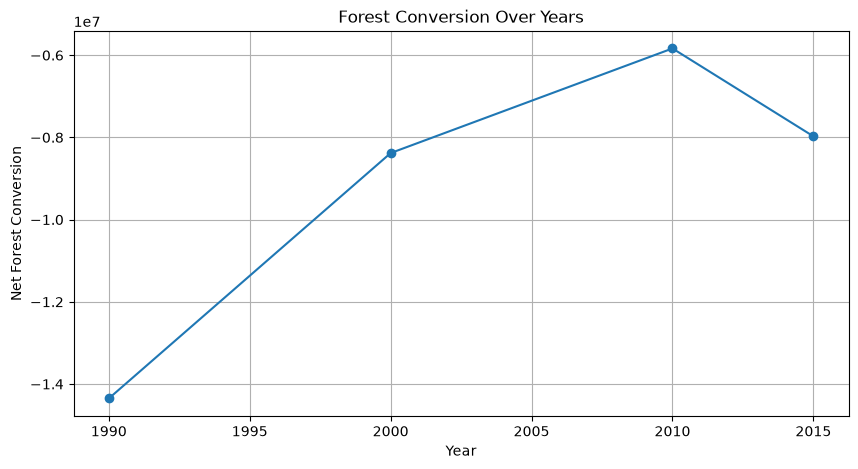

In [19]:
import matplotlib.pyplot as plt

yearly_data = df.groupby("Year")["Net forest conversion"].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_data.index, yearly_data.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Net Forest Conversion")
plt.title("Forest Conversion Over Years")

plt.grid(True)
plt.show()

In [20]:
country_data = df.groupby("Entity")["Net forest conversion"].sum()

top_10 = country_data.sort_values(ascending=False).head(10)

print(top_10)

Entity
China            8220540.0
India            1088600.0
United States     902000.0
Vietnam           652220.0
Russia            621910.0
Chile             445000.0
Turkey            357410.0
Australia         276070.0
Spain             150510.0
Cuba              149400.0
Name: Net forest conversion, dtype: float64


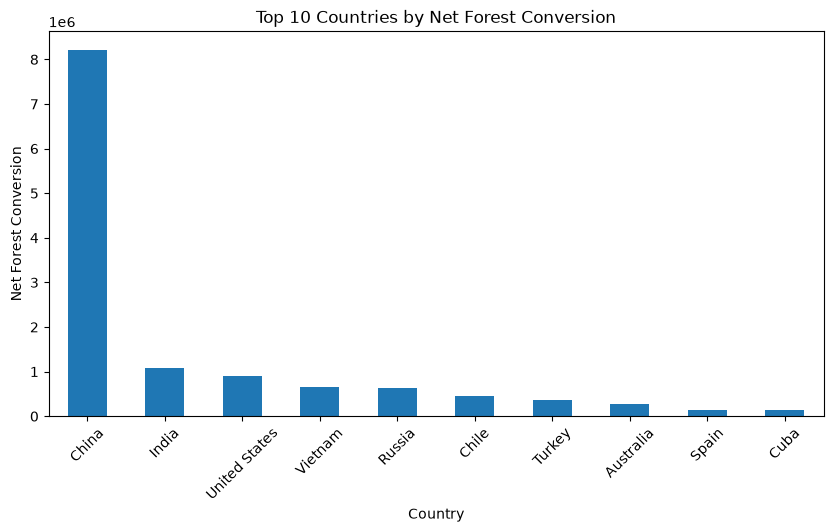

In [21]:
plt.figure(figsize=(10, 5))

top_10.plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Net Forest Conversion")
plt.title("Top 10 Countries by Net Forest Conversion")

plt.xticks(rotation=45)
plt.show()

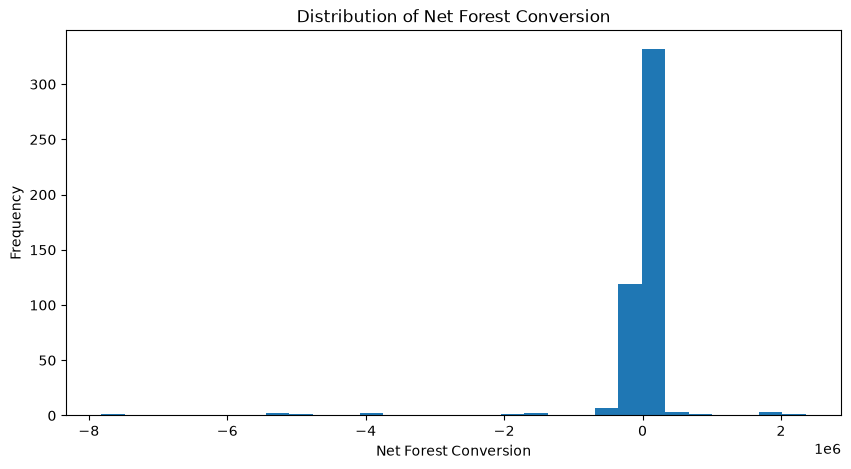

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(df["Net forest conversion"], bins=30)

plt.xlabel("Net Forest Conversion")
plt.ylabel("Frequency")
plt.title("Distribution of Net Forest Conversion")

plt.show()

In [23]:
df.to_csv("preprocessed_data.csv", index=False)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [24]:
import pandas as pd

df = pd.read_csv("annual-change-forest-area (1).csv")

In [25]:
df["Year_Since_2000"] = df["Year"] - 2000

df.head()

,Entity,Code,Year,Net forest conversion,Year_Since_2000
0,Algeria,DZA,1990,-8800.0,-10
1,Algeria,DZA,2000,33900.0,0
2,Algeria,DZA,2010,7600.0,10
3,Algeria,DZA,2015,-1400.0,15
4,Argentina,ARG,1990,-182600.0,-10


In [26]:
def categorize_conversion(value):
    if value < 0:
        return "Forest Loss"
    elif value > 0:
        return "Forest Gain"
    else:
        return "No Change"

df["Forest_Change_Category"] = df["Net forest conversion"].apply(
    categorize_conversion
)

df.head()

,Entity,Code,Year,Net forest conversion,Year_Since_2000,Forest_Change_Category
0,Algeria,DZA,1990,-8800.0,-10,Forest Loss
1,Algeria,DZA,2000,33900.0,0,Forest Gain
2,Algeria,DZA,2010,7600.0,10,Forest Gain
3,Algeria,DZA,2015,-1400.0,15,Forest Loss
4,Argentina,ARG,1990,-182600.0,-10,Forest Loss


In [27]:
print(df["Forest_Change_Category"].value_counts())

Forest_Change_Category
Forest Loss    225
Forest Gain    171
No Change       79
Name: count, dtype: int64


In [28]:
print("All Columns:")
print(df.columns.tolist())

All Columns:
['Entity', 'Code', 'Year', 'Net forest conversion', 'Year_Since_2000', 'Forest_Change_Category']


In [29]:
X = df[["Year_Since_2000", "Entity"]]
y = df["Forest_Change_Category"]

print("Selected Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Selected Features:
   Year_Since_2000     Entity
0              -10    Algeria
1                0    Algeria
2               10    Algeria
3               15    Algeria
4              -10  Argentina

Target:
0    Forest Loss
1    Forest Gain
2    Forest Gain
3    Forest Loss
4    Forest Loss
Name: Forest_Change_Category, dtype: str


In [30]:
X_encoded = pd.get_dummies(X, columns=["Entity"], drop_first=True)

print("Encoded Features:")
print(X_encoded.head())

Encoded Features:
   Year_Since_2000  Entity_Argentina  Entity_Aruba  Entity_Australia  \
0              -10             False         False             False   
1                0             False         False             False   
2               10             False         False             False   
3               15             False         False             False   
4              -10              True         False             False   

   Entity_Austria  Entity_Azerbaijan  Entity_Bahrain  Entity_Bangladesh  \
0           False              False           False              False   
1           False              False           False              False   
2           False              False           False              False   
3           False              False           False              False   
4           False              False           False              False   

   Entity_Belarus  Entity_Belgium  ...  Entity_United Kingdom  \
0           False           False

In [31]:
print("Final Feature List:")
print(X_encoded.columns.tolist())

Final Feature List:
['Year_Since_2000', 'Entity_Argentina', 'Entity_Aruba', 'Entity_Australia', 'Entity_Austria', 'Entity_Azerbaijan', 'Entity_Bahrain', 'Entity_Bangladesh', 'Entity_Belarus', 'Entity_Belgium', 'Entity_Belize', 'Entity_Bhutan', 'Entity_Bolivia', 'Entity_Brazil', 'Entity_Bulgaria', 'Entity_Burundi', 'Entity_Cameroon', 'Entity_Canada', 'Entity_Cape Verde', 'Entity_Cayman Islands', 'Entity_Central African Republic', 'Entity_Chile', 'Entity_China', 'Entity_Colombia', 'Entity_Congo', 'Entity_Costa Rica', 'Entity_Croatia', 'Entity_Cuba', 'Entity_Denmark', 'Entity_Djibouti', 'Entity_Dominican Republic', 'Entity_Ecuador', 'Entity_El Salvador', 'Entity_Equatorial Guinea', 'Entity_Estonia', 'Entity_Ethiopia', 'Entity_Falkland Islands', 'Entity_Faroe Islands', 'Entity_Finland', 'Entity_French Guyana', 'Entity_Gabon', 'Entity_Georgia', 'Entity_Germany', 'Entity_Gibraltar', 'Entity_Greenland', 'Entity_Guadeloupe', 'Entity_Guatemala', 'Entity_Guinea', 'Entity_Guyana', 'Entity_Hondura

In [32]:
print("Number of features:", X_encoded.shape[1])

Number of features: 132


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 380
Testing samples: 95


In [34]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [35]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
['Forest Loss' 'Forest Loss' 'Forest Loss' 'Forest Loss' 'Forest Loss'
 'Forest Loss' 'Forest Loss' 'Forest Loss' 'No Change' 'Forest Loss']


In [36]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.5210526315789473
Testing Accuracy: 0.49473684210526314


In [37]:
before_tuning = model.score(X_test, y_test)

print("Accuracy Before Tuning:", before_tuning)

Accuracy Before Tuning: 0.49473684210526314


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [39]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

after_tuning = best_model.score(X_test, y_test)

print("Accuracy After Tuning:", after_tuning)

Accuracy After Tuning: 0.8526315789473684


In [40]:
print("Performance Comparison")
print("----------------------")
print("Before Tuning:", before_tuning)
print("After Tuning :", after_tuning)

Performance Comparison
----------------------
Before Tuning: 0.49473684210526314
After Tuning : 0.8526315789473684


In [23]:
print(grid_search.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [25]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

after_tuning = best_model.score(X_test, y_test)

print("Accuracy After Tuning:", after_tuning)

Accuracy After Tuning: 0.8526315789473684


Confusion Matrix:
[[27  6  1]
 [ 5 40  0]
 [ 2  0 14]]


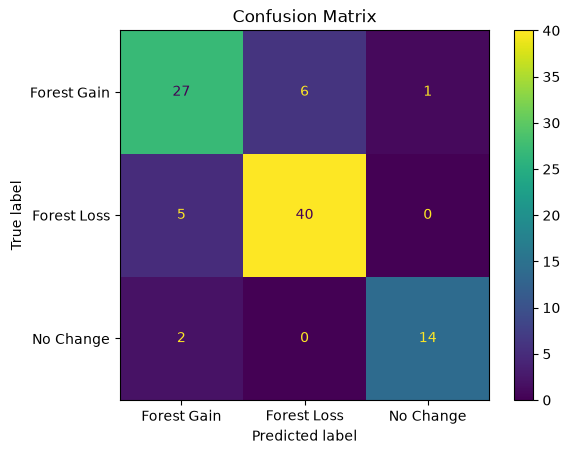

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_tuned)

precision = precision_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.8526315789473684
Precision: 0.853302822273074
Recall   : 0.8526315789473684
F1-Score : 0.8527584469859513


In [28]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Classification Report:
              precision    recall  f1-score   support

 Forest Gain       0.79      0.79      0.79        34
 Forest Loss       0.87      0.89      0.88        45
   No Change       0.93      0.88      0.90        16

    accuracy                           0.85        95
   macro avg       0.87      0.85      0.86        95
weighted avg       0.85      0.85      0.85        95



In [29]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9180483612018216


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_tuned)

precision = precision_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.8526315789473684
Precision: 0.853302822273074
Recall   : 0.8526315789473684
F1-Score : 0.8527584469859513


In [31]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Classification Report:
              precision    recall  f1-score   support

 Forest Gain       0.79      0.79      0.79        34
 Forest Loss       0.87      0.89      0.88        45
   No Change       0.93      0.88      0.90        16

    accuracy                           0.85        95
   macro avg       0.87      0.85      0.86        95
weighted avg       0.85      0.85      0.85        95



In [32]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9180483612018216


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest training completed!")

Random Forest training completed!


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test, rf_pred, average="weighted"
)

rf_recall = recall_score(
    y_test, rf_pred, average="weighted"
)

rf_f1 = f1_score(
    y_test, rf_pred, average="weighted"
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.8421052631578947
Precision: 0.8417932182234241
Recall   : 0.8421052631578947
F1-Score : 0.8418359331163731


In [35]:
print("Model Performance Summary")
print("-------------------------")
print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1-Score  : {f1:.2%}")
print(f"ROC-AUC   : {roc_auc:.2%}")

Model Performance Summary
-------------------------
Accuracy  : 85.26%
Precision : 85.33%
Recall    : 85.26%
F1-Score  : 85.28%
ROC-AUC   : 91.80%


In [36]:
new_data = pd.DataFrame({
    "Year_Since_2000": [20],
    "Entity": ["India"]
})

new_data_encoded = pd.get_dummies(
    new_data,
    columns=["Entity"],
    drop_first=True
)

new_data_encoded = new_data_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

prediction = best_model.predict(new_data_encoded)

print("Sample Input:")
print(new_data)

print("\nPredicted Forest Change:")
print(prediction[0])

Sample Input:
   Year_Since_2000 Entity
0               20  India

Predicted Forest Change:
Forest Loss


In [37]:
new_data = pd.DataFrame({
    "Year_Since_2000": [20, 15, 10],
    "Entity": ["India", "Brazil", "China"]
})

new_data_encoded = pd.get_dummies(
    new_data,
    columns=["Entity"],
    drop_first=True
)

new_data_encoded = new_data_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

predictions = best_model.predict(new_data_encoded)

new_data["Predicted Forest Change"] = predictions

print(new_data)

   Year_Since_2000  Entity Predicted Forest Change
0               20   India             Forest Gain
1               15  Brazil             Forest Loss
2               10   China             Forest Gain
